## MODELO REGRESIÓN LOGÍSTICA ANÁLISIS SENTIMIENTO

In [3]:
import pandas as pd
import nltk
import string
import random
import pickle

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy

CARGA DE DATOS DE ENTRENAMIENTO

In [5]:
df = pd.read_excel(r"Z:\00 COMUN PRESTACIONES Y PROVEEDORES\NPS_POWER_BI\Copias\00_NPS\Pruebas\analisis_salud.xlsx")

CREAR UN NUEVO DATAFRAME A PARTIR DE ESTE QUE CONTENGA UNICAMENTE EL TEXTO, LA ETIQUETA Y EL IDENTIFICADOR

In [ ]:
columnas_necesarias = [
    "Surveyid for internal use (e.g. RI link)",
    "texto_norm",
    "sentimiento",
    "confianza"
]

df = df[columnas_necesarias]

import re

def texto_valido(texto):
    if not isinstance(texto, str):
        return False
    texto = texto.strip()
    if texto == "":
        return False
    if len(texto) < 3:
        return False
    # comprobar que tenga al menos una letra
    if not re.search(r"[a-zA-ZáéíóúÁÉÍÓÚñÑ]", texto):
        return False
    return True

df = df[df["texto_norm"].apply(texto_valido)]

df["confianza"] = pd.to_numeric(df["confianza"], errors="coerce")
df = df[df["confianza"] >= 0.95]

print(df.head)
print(df.shape)

   Surveyid for internal use (e.g. RI link)  \
0                               138667208.0   
2                               138470303.0   
3                               138469493.0   
4                               138669546.0   
5                               138666446.0   

                                          texto_norm sentimiento  confianza  
0                                  gran profesional.    Positivo   0.998705  
2  siempre encuentro un especialista cerca y sino...    Positivo   0.998390  
3  la cuota mensual a pagar ha ido aumentando con...    Positivo   0.992788  
4  amabilidad, rápida respuesta y resolución de g...    Positivo   0.998028  
5  se podría mejorar haciendo coincidir las difer...    Positivo   0.994793  
(83982, 4)


PREPROCESAMIENTO DEL TEXTO

In [7]:
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(texto)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df["tokens_limpios"] = df["texto_norm"].apply(limpiar_texto)
df = df[df["tokens_limpios"].str.len() > 0]

ENTRENAMIENTO

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# X e y
X = df["texto_modelo"]   
y = df["sentimiento"]   

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),   # añade trigramas
    min_df=3,             # más vocabulario
    max_df=0.85,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    class_weight="balanced",
    solver="liblinear"
)

model.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8566231287648357


VALIDACIÓN CRUZADA

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Accuracy por fold:", scores)
print("Accuracy medio CV:", scores.mean())
print("Desviación:", scores.std())

Accuracy por fold: [0.85112569 0.85470404 0.84784553 0.85581153 0.85417133]
Accuracy medio CV: 0.8527316234210893
Desviación: 0.002894887313887927


GUARDAR EL MODELO

In [ ]:
import joblib

joblib.dump(model, "modelo_sentimiento_logreg.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

CARGAR MODELO

In [ ]:
model = joblib.load("modelo_sentimiento_logreg.pkl")
vectoriZer = joblib.load("tfidf_vectorizer.pkl")

## MÉTRICAS SOBRE ERRORES

MATRIZ DE CONfUSIÓN

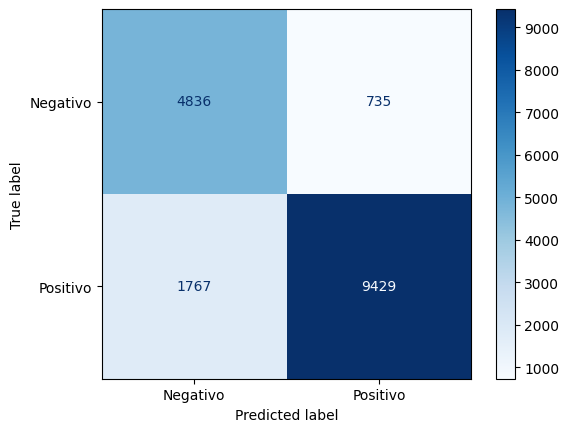

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.show()

PRECISION / RECALL / F1 POR CLASE

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negativo       0.73      0.87      0.79      5571
    Positivo       0.93      0.84      0.88     11196

    accuracy                           0.85     16767
   macro avg       0.83      0.86      0.84     16767
weighted avg       0.86      0.85      0.85     16767



ANÁLISIS DE ERRORES

In [22]:
df_errores = X_test.to_frame(name="texto")
df_errores["real"] = y_test.values
df_errores["predicho"] = y_pred

df_errores = df_errores[df_errores["real"] != df_errores["predicho"]]

df_errores.head(10)

,texto,real,predicho
35998,atención fantástica único tardaron darme habit...,Positivo,Negativo
41467,iba dolor hombro brazo explicó hizo ecografia,Positivo,Negativo
53966,ninguna quejagracias,Positivo,Negativo
24407,proximidad especialistas dermatologo otrosen p...,Positivo,Negativo
26974,normal,Positivo,Negativo
11414,diciembre dijeron llamarían darme cita cambio ...,Positivo,Negativo
78726,asisti centro gabimedi tordera consulta dermat...,Positivo,Negativo
45925,servicios zona madrid volver cubrir ondas choq...,Positivo,Negativo
83310,tardan cualquier analítica,Negativo,Positivo
101289,pues hacer reembolsos ninguno casos realizado ...,Negativo,Positivo
